In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.linear_model import LinearRegression 

sns.set()

In [3]:
cleaned_data = pd.read_csv('cleaned_data.csv')

In [8]:
cleaned_data.columns

Index(['Brand', 'Price', 'Body', 'Mileage', 'EngineV', 'Engine Type',
       'Registration', 'Year'],
      dtype='object')

Text(0.5, 1.0, 'Price and Mileage')

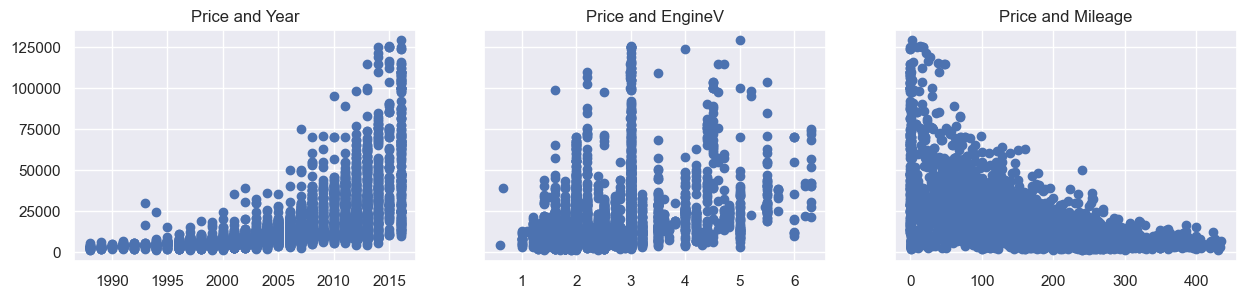

In [10]:
f , (ax1,ax2,ax3) = plt.subplots(1,3 , sharey=True, figsize = (15,3))
ax1.scatter(cleaned_data['Year'], cleaned_data['Price'])
ax1.set_title('Price and Year')
ax2.scatter(cleaned_data['EngineV'], cleaned_data['Price'])
ax2.set_title('Price and EngineV')
ax3.scatter(cleaned_data['Mileage'], cleaned_data['Price'])
ax3.set_title('Price and Mileage')

## As we can see all the scatter data plotted works on side like they are exponential with price

C:\Users\kushw\AppData\Local\Temp\ipykernel_15848\590189951.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(cleaned_data['Price'])


<Axes: xlabel='Price', ylabel='Density'>

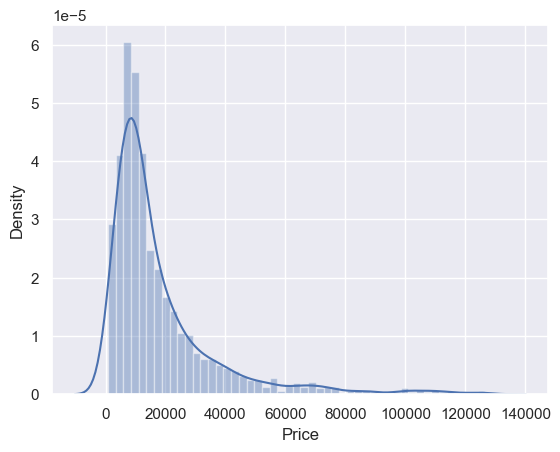

In [11]:
sns.distplot(cleaned_data['Price'])

As it's Exponential so we need to convert it in to log value to run linear regression.

In [14]:
cleaned_data['log price'] = np.log(cleaned_data['Price'])
cleaned_data

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,log price
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,8.342840
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,8.974618
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,9.495519
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,10.043249
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,9.814656
...,...,...,...,...,...,...,...,...,...
3862,Volkswagen,11500.0,van,163,2.5,Diesel,yes,2008,9.350102
3863,Toyota,17900.0,sedan,35,1.6,Petrol,yes,2014,9.792556
3864,Mercedes-Benz,125000.0,sedan,9,3.0,Diesel,yes,2014,11.736069
3865,BMW,6500.0,sedan,1,3.5,Petrol,yes,1999,8.779557


In [19]:
cleaned_data = cleaned_data.drop('Price',axis=1)

## Pllotting Mileage, Year and EngineV with log Price

Text(0.5, 1.0, 'Price and Mileage')

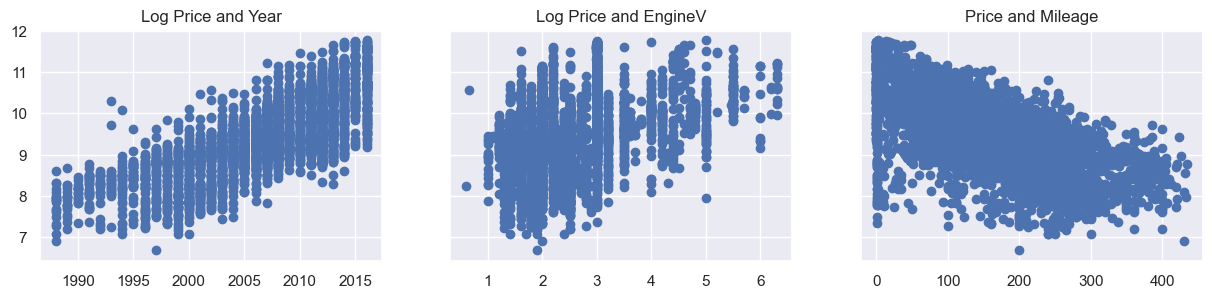

In [18]:
f , (ax1,ax2,ax3) = plt.subplots(1,3 , sharey=True, figsize = (15,3))
ax1.scatter(cleaned_data['Year'], cleaned_data['log price'])
ax1.set_title('Log Price and Year')
ax2.scatter(cleaned_data['EngineV'], cleaned_data['log price'])
ax2.set_title('Log Price and EngineV')
ax3.scatter(cleaned_data['Mileage'], cleaned_data['log price'])
ax3.set_title('Price and Mileage')

As now we can see an linearity in between varibles.

In [20]:
cleaned_data.columns.values

array(['Brand', 'Body', 'Mileage', 'EngineV', 'Engine Type',
       'Registration', 'Year', 'log price'], dtype=object)

## Multicollinearity

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
variable = cleaned_data[['Mileage', "EngineV", 'Year']]
vif = pd.DataFrame()
vif['VIF'] = [variance_inflation_factor(variable.values , i) for i in range(variable.shape[1])]
vif['features'] = variable.columns

In [27]:
vif

,VIF,features
0,3.791584,Mileage
1,7.662068,EngineV
2,10.354854,Year


VIF = 1 : NO multicolinearity,
1 < VIF < 5  : Perfect okay,
10 < VIF : Unacceptable

In [28]:
data_no_multicollinearity = cleaned_data.drop('Year', axis=1)

In [29]:
data_no_multicollinearity.to_csv('data no multicollinearity.csv', index=False)